# 1. Atraso X Inadimplência

                       taxa  clientes
status_ultimo_mes                    
Sem uso            0.132294      2759
Pagou total        0.167781      5686
Pagou mínimo       0.128113     14737
1 mês atraso       0.339479      3688
2 meses atraso     0.691414      2667
3+ meses atraso    0.719222       463


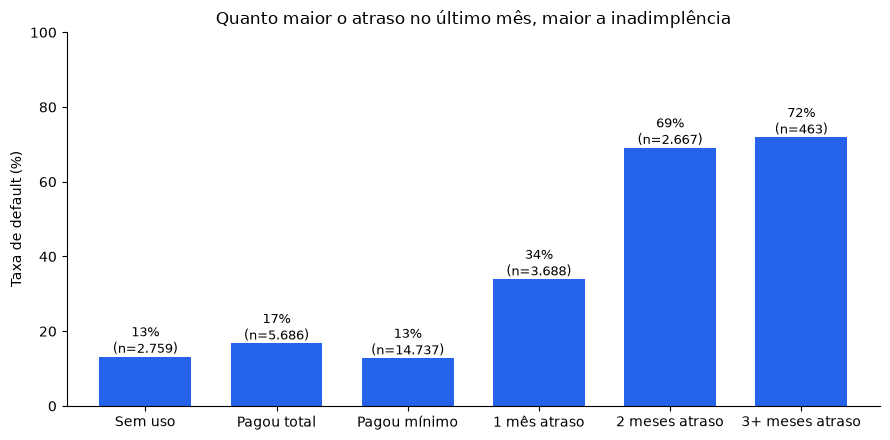

In [7]:
import sys; sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import load_raw, clean

df = clean(load_raw("../data/raw/default of credit card clients.xls"))

def status_pagamento(v):
    if v == -2: return "Sem uso"
    if v == -1: return "Pagou total"
    if v == 0:  return "Pagou mínimo"
    if v == 1:  return "1 mês atraso"
    if v == 2:  return "2 meses atraso"
    return "3+ meses atraso"

ordem = ["Sem uso", "Pagou total", "Pagou mínimo",
         "1 mês atraso", "2 meses atraso", "3+ meses atraso"]
df["status_ultimo_mes"] = pd.Categorical(
    df["PAY_1"].apply(status_pagamento), categories=ordem, ordered=True)

tab = df.groupby("status_ultimo_mes", observed=True)["default"].agg(taxa="mean", clientes="count")
print(tab)

ax = (tab["taxa"] * 100).plot(kind="bar", color="#2563EB", width=0.7, figsize=(9, 4.5))
for i, (taxa, n) in enumerate(zip(tab["taxa"], tab["clientes"])):
    ax.text(i, taxa * 100 + 1, f"{taxa:.0%}\n(n={n:,})".replace(",", "."), ha="center", fontsize=9)
ax.set_title("Quanto maior o atraso no último mês, maior a inadimplência")
ax.set_xlabel("")
ax.set_ylabel("Taxa de default (%)")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Taxa de inadimplência por uso do limite do cartão

                      taxa  clientes
faixa_uso_limite                    
Sem fatura        0.247498      2598
Até 10%           0.169829      8644
10–30%            0.168122      3551
30–50%            0.225203      2833
50–80%            0.263314      4394
80–100%           0.255243      5865
Acima do limite   0.300709      2115


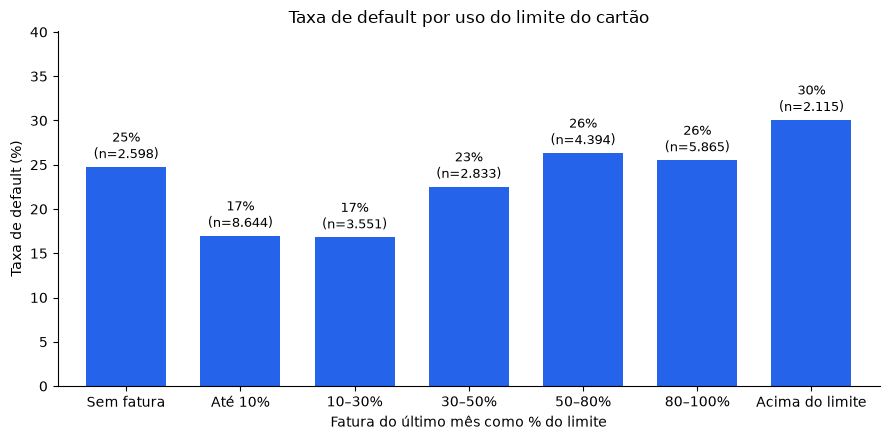

In [9]:
import sys; sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import load_raw, clean
import numpy as np

df = clean(load_raw("../data/raw/default of credit card clients.xls"))

df["utilizacao"] = df["BILL_AMT1"] / df["LIMIT_BAL"]
faixas = [-np.inf, 0, 0.1, 0.3, 0.5, 0.8, 1.0, np.inf]
rotulos = ["Sem fatura", "Até 10%", "10–30%", "30–50%", "50–80%", "80–100%", "Acima do limite"]
df["faixa_uso_limite"] = pd.cut(df["utilizacao"], bins=faixas, labels=rotulos)

tab = df.groupby("faixa_uso_limite", observed=True)["default"].agg(taxa="mean", clientes="count")
print(tab)

ax = (tab["taxa"] * 100).plot(kind="bar", color="#2563EB", width=0.7, figsize=(9, 4.5))
for i, (taxa, n) in enumerate(zip(tab["taxa"], tab["clientes"])):
    ax.text(i, taxa * 100 + 1, f"{taxa:.0%}\n(n={n:,})".replace(",", "."), ha="center", fontsize=9)
ax.set_title("Taxa de default por uso do limite do cartão")
ax.set_xlabel("Fatura do último mês como % do limite")
ax.set_ylabel("Taxa de default (%)")
ax.set_ylim(0, tab["taxa"].max() * 100 + 10)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. O cliente está melhorando ou piorando?

                      taxa  clientes  % da base
tendencia                                      
Sempre em dia     0.117104     19931      0.664
Regularizou       0.224678      1629      0.054
Atrasa sempre     0.591653      3546      0.118
Passou a atrasar  0.375562      4894      0.163


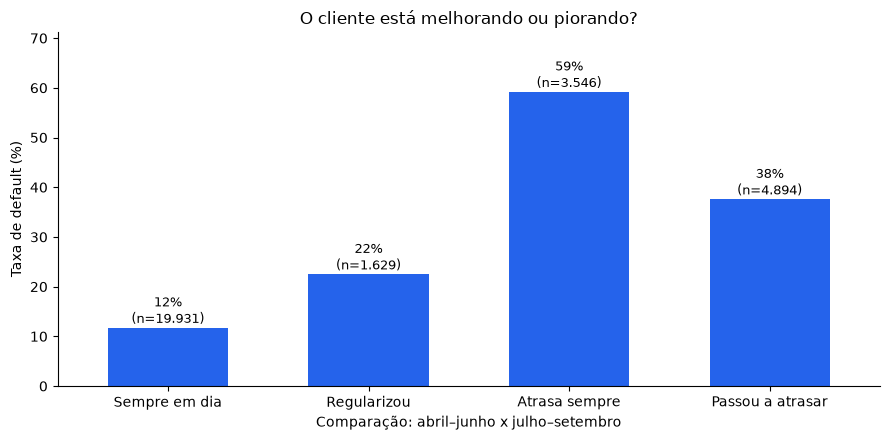

In [11]:
import sys; sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import load_raw, clean
import numpy as np

df = clean(load_raw("../data/raw/default of credit card clients.xls"))

antigos = ["PAY_6", "PAY_5", "PAY_4"]    # abril, maio, junho
recentes = ["PAY_3", "PAY_2", "PAY_1"]   # julho, agosto, setembro

df["atrasos_antigos"] = (df[antigos] > 0).sum(axis=1)
df["atrasos_recentes"] = (df[recentes] > 0).sum(axis=1)

condicoes = [
    (df["atrasos_antigos"] == 0) & (df["atrasos_recentes"] == 0),
    (df["atrasos_antigos"] > 0) & (df["atrasos_recentes"] == 0),
    (df["atrasos_antigos"] > 0) & (df["atrasos_recentes"] > 0),
    (df["atrasos_antigos"] == 0) & (df["atrasos_recentes"] > 0),
]
ordem = ["Sempre em dia", "Regularizou", "Atrasa sempre", "Passou a atrasar"]
df["tendencia"] = pd.Categorical(
    np.select(condicoes, ordem, default="Outro"), categories=ordem, ordered=True)

tab = df.groupby("tendencia", observed=True)["default"].agg(taxa="mean", clientes="count")
tab["% da base"] = (tab["clientes"] / len(df)).round(3)
print(tab)

ax = (tab["taxa"] * 100).plot(kind="bar", color="#2563EB", width=0.6, figsize=(9, 4.5))
for i, (taxa, n) in enumerate(zip(tab["taxa"], tab["clientes"])):
    ax.text(i, taxa * 100 + 1, f"{taxa:.0%}\n(n={n:,})".replace(",", "."), ha="center", fontsize=9)
ax.set_title("O cliente está melhorando ou piorando?")
ax.set_xlabel("Comparação: abril–junho x julho–setembro")
ax.set_ylabel("Taxa de default (%)")
ax.set_ylim(0, tab["taxa"].max() * 100 + 12)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()